In [79]:
!pip install -q medmnist

In [80]:
! pip install -q neptune

In [81]:
!pip install -q pytorch-msssim

In [82]:
NEPTUNE_PROJECT_NAME = "sigk/data-generation"
NEPTUNE_API_KEY = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZmIwZTU3OS0xZmJjLTRiZjEtODZmNS0yOGI2NjI1ZjE4NDgifQ=="

In [83]:
import os
import random
from datetime import datetime

import matplotlib.pyplot as plt
import medmnist
import neptune
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from medmnist import INFO, Evaluator
from pytorch_msssim import ssim
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from torchvision import models, transforms
from torchvision.utils import save_image
from tqdm import tqdm

In [84]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [85]:
data_flag = 'bloodmnist'
# data_flag = 'dermamnist'
# data_flag = 'pathmnist'
download = True

NUM_EPOCHS = 10
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [86]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_vae_dataset = DataClass(split='train', transform=data_transform, download=download)
test_vae_dataset = DataClass(split='test', transform=data_transform, download=download)
pil_dataset = DataClass(split='train', download=download)

train_vae_loader = data.DataLoader(dataset=train_vae_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_vae_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_vae_loader = data.DataLoader(dataset=test_vae_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [87]:
train_vae_dataset.montage(length=1)

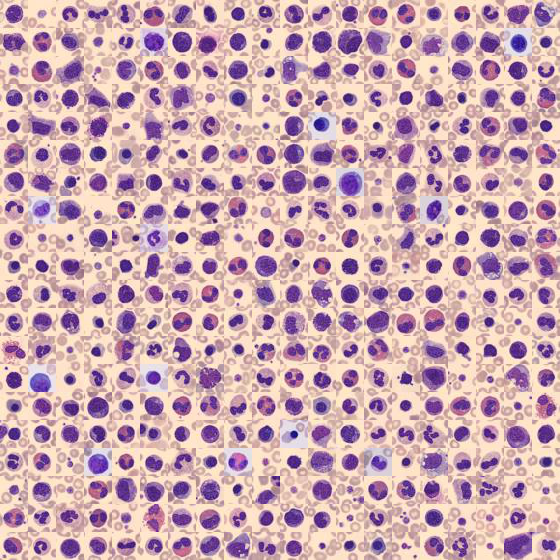

In [88]:
test_vae_dataset.montage(length=20)

In [89]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=64, input_channels=3, input_size=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_size = input_size
        self.final_size = input_size // 8  # 64 → 32 → 16 → 8

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 64, 4, stride=2, padding=1),   # 64 → 32
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),              # 32 → 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),             # 16 → 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )

        flat_dim = 256 * self.final_size * self.final_size
        self.fc_mu = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv(x)
        x = x.view(batch_size, -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [90]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=64, output_channels=3, output_size=64):
        super().__init__()
        assert output_size % 8 == 0
        self.init_size = output_size // 8  # 8

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256 * self.init_size * self.init_size),
            nn.LeakyReLU(0.2),
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),  # 8 → 16
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),  # 16 → 32
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),  # 32 → 64
            nn.Conv2d(64, output_channels, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        img = self.upsample(out)
        return img


In [91]:
class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_channels, 32, 4, stride=2, padding=1),  # 64 → 32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 32 → 16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 1, 4, stride=2, padding=0),  # 16 → 7
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

In [92]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [93]:
def vae_gan_loss(
    recon_x, x, mu, logvar, d_real, d_fake,
    beta=1.0, gamma=2.0
):
    # Rekonstrukcja: BCE
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KLD
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # GAN loss (dla generatora)
    valid = torch.ones_like(d_fake)
    gan_loss = F.binary_cross_entropy(d_fake, valid)

    # total = recon_loss + beta * kld
    total = recon_loss + gamma * gan_loss + beta * kld
    return total, recon_loss, gan_loss, kld

In [94]:
def plot_predictions_vae(
    encoder: torch.nn.Module,
    decoder: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    n: int = 5,
    latent_dim: int = 100,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    show: bool = True
) -> plt.Figure:
    encoder.eval()
    decoder.eval()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))

    with torch.no_grad():
        for i, (real_images, _) in enumerate(val_loader):
            if i >= n:
                break

            real_images = real_images.to(device)
            x = real_images[0].unsqueeze(0)

            mu, logvar = encoder(x)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            # Ground Truth
            ax_gt = axes[0, i]
            img_gt = x[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            ax_gt.imshow(img_gt)
            ax_gt.set_title(f"Real {i+1}")

            # Reconstruction
            ax_recon = axes[1, i]
            img_recon = recon[0].cpu().permute(1, 2, 0).numpy().clip(0, 1)
            ax_recon.imshow(img_recon)
            ax_recon.set_title(f"Recon {i+1}")

        axes[0, 0].set_ylabel('Ground Truth', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Reconstruction', fontsize=12, fontweight='bold')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout(pad=0.5)
    if show:
        plt.show()

    plt.close()
    return fig


In [95]:
def train_vae_gan(
    encoder,
    decoder,
    discriminator,
    optimizer_vae,
    optimizer_d,
    train_loader,
    val_loader,
    num_epochs=20,
    pretrain_epochs=5,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    run=None,
    latent_dim=256,
):
    encoder.to(device)
    decoder.to(device)
    discriminator.to(device)

    for epoch in range(num_epochs):
        encoder.train()
        decoder.train()
        discriminator.train()

        total_vae_loss = 0.0
        total_recon = 0.0
        total_kld = 0.0
        total_gan = 0.0
        total_d = 0.0
        total_samples = 0

        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            batch_size = imgs.size(0)
            total_samples += batch_size

            mu, logvar = encoder(imgs)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            if epoch >= pretrain_epochs:
                # === Train Discriminator ===
                real_pred = discriminator(imgs.detach())
                fake_pred_d = discriminator(recon.detach())

                valid = torch.full_like(real_pred, 0.8)
                fake = torch.full_like(fake_pred_d, 0.2)

                d_loss_real = F.binary_cross_entropy(real_pred, valid, reduction='sum')
                d_loss_fake = F.binary_cross_entropy(fake_pred_d, fake, reduction='sum')
                d_loss = (d_loss_real + d_loss_fake) / 2

                optimizer_d.zero_grad()
                d_loss.backward()
                optimizer_d.step()

                # === Train VAE + GAN ===
                fake_pred_g = discriminator(recon)
                vae_loss, recon_loss, gan_loss, kld = vae_gan_loss(
                    recon_x=recon,
                    x=imgs,
                    mu=mu,
                    logvar=logvar,
                    d_real=real_pred,
                    d_fake=fake_pred_g,
                    beta=1.0,
                    gamma=4.0
                )
            else:
                d_loss = torch.tensor(0.0, device=device)
                gan_loss = torch.tensor(0.0, device=device)
                recon_loss = F.binary_cross_entropy(recon, imgs, reduction='sum')
                kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                vae_loss = recon_loss + kld

            optimizer_vae.zero_grad()
            vae_loss.backward()
            optimizer_vae.step()

            # Suma wartości (dzielona potem przez total_samples)
            total_vae_loss += vae_loss.item()
            total_recon += recon_loss.item()
            total_gan += gan_loss.item()
            total_kld += kld.item()
            total_d += d_loss.item()

        # Średnie per próbka
        log_vals = {
            "loss": total_vae_loss / total_samples,
            "recon": total_recon / total_samples,
            "gan": total_gan / total_samples,
            "kld": total_kld / total_samples,
            "d_loss": total_d / total_samples,
        }

        print(f"Epoch {epoch+1}: " + " | ".join([f"{k.upper()} {v:.4f}" for k, v in log_vals.items()]))

        if run:
            for key, val in log_vals.items():
                run[f"train/epoch/{key}"].append(val)

            # Log samples
            encoder.eval()
            decoder.eval()
            with torch.no_grad():
                fig = plot_predictions_vae(
                    encoder=encoder,
                    decoder=decoder,
                    val_loader=val_loader,
                    n=4,
                    latent_dim=latent_dim,
                    device=device,
                    show=False
                )
                run[f"train/epoch/{epoch+1}_samples"].upload(
                    neptune.types.File.as_image(fig)
                )
            encoder.train()
            decoder.train()

In [96]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64

encoder = Encoder(latent_dim=latent_dim, input_channels=3, input_size=64).to(device)
decoder = Decoder(latent_dim=latent_dim, output_channels=3, output_size=64).to(device)
discriminator = Discriminator(input_channels=3).to(device)

lr = 1e-3
optimizer_vae = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
epochs = 200

In [97]:
run = neptune.init_run(
    project=NEPTUNE_PROJECT_NAME,
    api_token=NEPTUNE_API_KEY,
)
params = {
    "encoder_name": encoder.__class__.__name__,
    "decoder_name": decoder.__class__.__name__,
    "optimizer_vae_name": optimizer_vae.__class__.__name__,
    "optimizer_d_name": optimizer_d.__class__.__name__,
    "learning_rate": lr,
    "epochs": epochs,
    "dataset_size": len(train_vae_dataset),
    "dataset_version": data_flag,
    "batch_size": BATCH_SIZE,
}
run["parameters"] = params

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/sigk/data-generation/e/DAT-40


In [98]:
start_time = datetime.now()

train_vae_gan(
    encoder=encoder,
    decoder=decoder,
    discriminator=discriminator,
    optimizer_vae=optimizer_vae,
    optimizer_d=optimizer_d,
    train_loader=train_vae_loader,
    val_loader=test_vae_loader,
    num_epochs=epochs,
    device=device,
    run=run,
    latent_dim=latent_dim
)

train_time = datetime.now() - start_time
print(f"Training time: {train_time}")
run["train/time"] = train_time.seconds


Epoch 1: LOSS 6527.3063 | RECON 6476.9327 | GAN 0.0000 | KLD 50.3737 | D_LOSS 0.0000
Epoch 2: LOSS 6301.0461 | RECON 6249.4248 | GAN 0.0000 | KLD 51.6213 | D_LOSS 0.0000
Epoch 3: LOSS 6275.2832 | RECON 6221.0431 | GAN 0.0000 | KLD 54.2401 | D_LOSS 0.0000
Epoch 4: LOSS 6258.2058 | RECON 6203.8449 | GAN 0.0000 | KLD 54.3609 | D_LOSS 0.0000
Epoch 5: LOSS 6247.8561 | RECON 6193.4606 | GAN 0.0000 | KLD 54.3955 | D_LOSS 0.0000
Epoch 6: LOSS 6239.2890 | RECON 6184.7644 | GAN 0.0056 | KLD 54.5023 | D_LOSS 34.6198
Epoch 7: LOSS 6228.4587 | RECON 6174.5375 | GAN 0.0055 | KLD 53.8991 | D_LOSS 34.2334
Epoch 8: LOSS 6222.7388 | RECON 6169.1064 | GAN 0.0055 | KLD 53.6103 | D_LOSS 34.0798
Epoch 9: LOSS 6215.8546 | RECON 6162.9437 | GAN 0.0055 | KLD 52.8887 | D_LOSS 33.8742
Epoch 10: LOSS 6211.7757 | RECON 6159.0605 | GAN 0.0061 | KLD 52.6909 | D_LOSS 32.3069
Epoch 11: LOSS 6207.1637 | RECON 6154.9125 | GAN 0.0077 | KLD 52.2206 | D_LOSS 29.1394
Epoch 12: LOSS 6204.8948 | RECON 6153.0853 | GAN 0.0091 |

In [99]:
run.stop()

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 7 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 7 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/sigk/data-generation/e/DAT-40/metadata


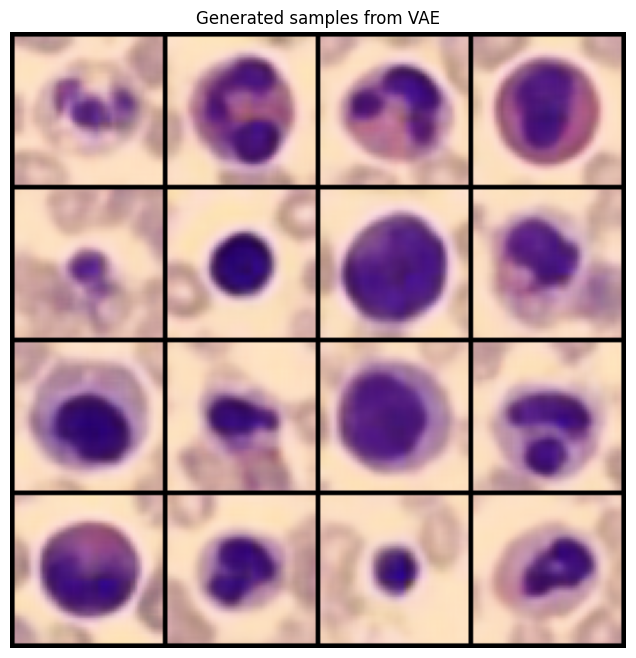

In [100]:
decoder.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)  # latent_dim taki sam jak w trenowaniu
    samples = decoder(z)  # [16, 3, 64, 64]

    # Tworzymy grid 4x4 z normalizacją do [0,1]
    grid_img = torchvision.utils.make_grid(samples, nrow=4, normalize=True)

    # Wyświetlamy obrazek
    plt.figure(figsize=(8,8))
    plt.imshow(grid_img.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Generated samples from VAE')
    plt.show()


## Resnet50 Experiment training setups


In [101]:
def show_samples(dataset, n=9, title="Sample Images"):
    loader = torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)
    imgs, labels = next(iter(loader))

    # Jeśli dane są znormalizowane (np. do [-1, 1] albo [0, 1] ze standard score)
    if imgs.min() < 0 or imgs.max() > 1:
        imgs = (imgs + 1) / 2  # zakładając normalizację do [-1, 1]

    grid = torchvision.utils.make_grid(imgs, nrow=int(n**0.5), normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(title)
    plt.show()

In [102]:
# preprocessing
data_transform_resnet  = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset_original = DataClass(split='train', transform=data_transform_resnet , download=download)
test_dataset_original = DataClass(split='test', transform=data_transform_resnet , download=download)
pil_dataset = DataClass(split='train', download=download)

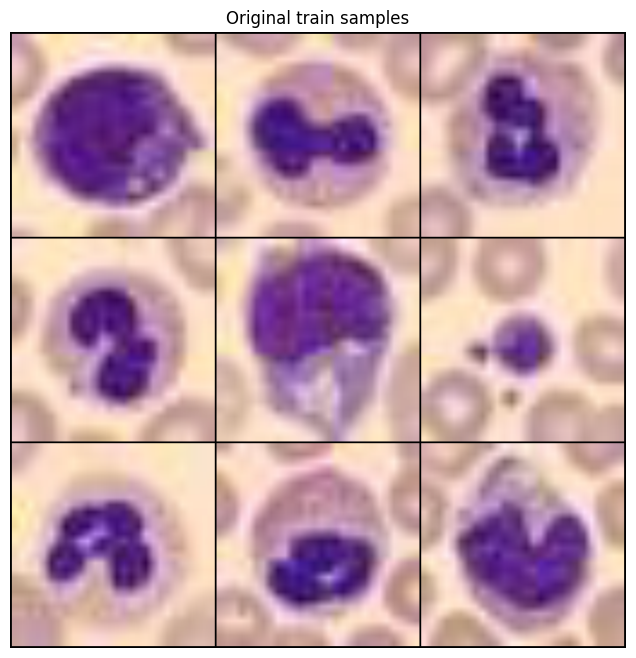

In [103]:
show_samples(train_dataset_original, n=9, title="Original train samples")

In [104]:
class GeneratedDataset(Dataset):
    def __init__(self, encoder, decoder, real_dataset, transform=None, device='cuda'):
        self.encoder = encoder
        self.decoder = decoder
        self.real_dataset = real_dataset  # dataset z etykietami
        self.transform = transform
        self.device = device
        self.generated_data = []
        self.generate()

    def generate(self):
        self.encoder.eval()
        self.decoder.eval()

        with torch.no_grad():
            for x, label in self.real_dataset:
                x = x.unsqueeze(0).to(self.device)  # [1, C, H, W]
                mu, logvar = self.encoder(x)
                z = reparameterize(mu, logvar)
                gen = self.decoder(z).squeeze(0).cpu()  # [C, H, W]
                self.generated_data.append((gen, label))

    def __len__(self):
        return len(self.generated_data)

    def __getitem__(self, idx):
        img, label = self.generated_data[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


In [105]:
data_transform_generated = transforms.Compose([
    transforms.Resize((224, 224)),  # dopasowanie do rozmiaru ResNeta
    transforms.Normalize(mean=[.5], std=[.5])
])

In [106]:
n_train_generated = len(train_dataset_original)
n_test_generated = len(test_dataset_original)

train_dataset_generated = GeneratedDataset(
    encoder=encoder,
    decoder=decoder,
    real_dataset=train_vae_dataset,
    transform=data_transform_generated,
    device=device
)

test_dataset_generated = GeneratedDataset(
    encoder=encoder,
    decoder=decoder,
    real_dataset=test_vae_dataset,
    transform=data_transform_generated,
    device=device
)

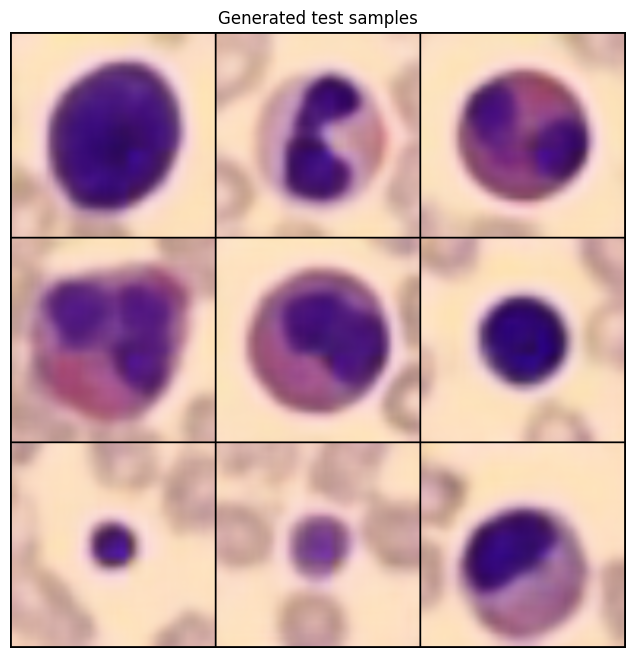

In [107]:
show_samples(test_dataset_generated, n=9, title="Generated test samples")

In [108]:
# Ustal losowe, niepokrywające się podzbiory
indices = list(range(n_train_generated))
random.shuffle(indices)
half = n_train_generated // 2
train_orig_half_idx = indices[:half]
train_gen_half_idx = indices[half:]

# Podzbiory
train_orig_half = Subset(train_dataset_original, train_orig_half_idx)
train_gen_half = Subset(train_dataset_generated, train_gen_half_idx)

# MIX bez duplikatów semantycznych
train_dataset_mix = ConcatDataset([train_orig_half, train_gen_half])

In [109]:
indices = list(range(n_test_generated))
random.shuffle(indices)
half = n_test_generated // 2
test_orig_half_idx = indices[:half]
test_gen_half_idx = indices[half:]

test_orig_half = Subset(test_dataset_original, test_orig_half_idx)
test_gen_half = Subset(test_dataset_generated, test_gen_half_idx)

test_dataset_mix = ConcatDataset([test_orig_half, test_gen_half])

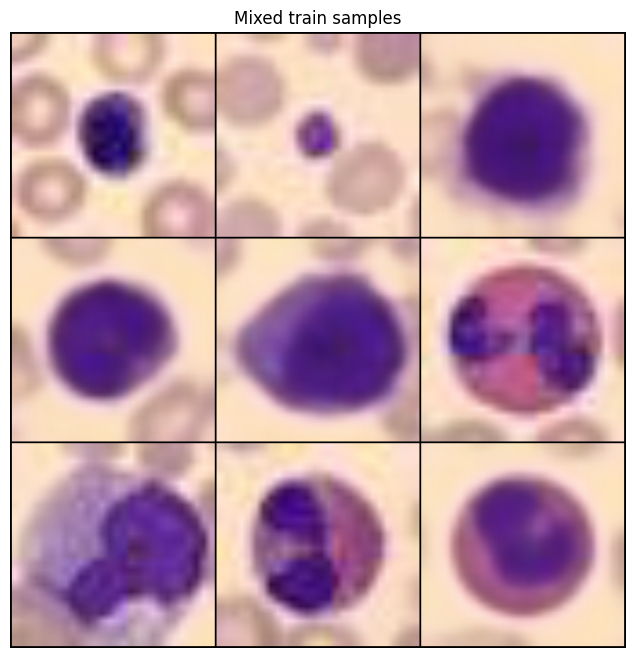

In [110]:
show_samples(test_dataset_mix, n=9, title="Mixed train samples")

In [111]:
class Resnet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Resnet, self).__init__()

        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        for param in self.model.parameters():
          param.requires_grad = False

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [112]:
train_loader = data.DataLoader(dataset=train_dataset_original, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(dataset=test_dataset_original, batch_size=2*BATCH_SIZE, shuffle=False)

train_loader_generated = data.DataLoader(dataset=train_dataset_generated, batch_size=BATCH_SIZE, shuffle=True)
test_loader_generated = data.DataLoader(dataset=test_dataset_generated, batch_size=2*BATCH_SIZE, shuffle=False)

train_loader_mix = data.DataLoader(dataset=train_dataset_mix, batch_size=BATCH_SIZE, shuffle=True)
test_loader_mix = data.DataLoader(dataset=test_dataset_mix, batch_size=2*BATCH_SIZE, shuffle=False)

In [113]:
def train_model(model, train_loader, optimizer, criterion, device, task, num_epochs=10):
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                loss = criterion(outputs, targets)
            else:
                targets = targets.squeeze().long()
                loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"[Epoch {epoch+1}] Loss: {epoch_loss / len(train_loader):.4f}")


In [114]:
def test(data_loader, split="val"):
    model.eval()
    y_true = torch.tensor([], device=device)
    y_score = torch.tensor([], device=device)

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.sigmoid()
            else:
                targets = targets.squeeze().long()
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)

            y_true = torch.cat((y_true, targets), dim=0)
            y_score = torch.cat((y_score, outputs), dim=0)

    y_true = y_true.cpu().numpy()
    y_score = y_score.detach().cpu().numpy()

    evaluator = Evaluator(data_flag, split)
    metrics = evaluator.evaluate(y_score)

    print(f"{split}  auc: {metrics[0]:.3f}  acc: {metrics[1]:.3f}")


## Training: original, Testing: generated & original


In [115]:
model = Resnet(in_channels=n_channels, num_classes=n_classes)
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=lr)

In [116]:
train_model(
    model=model,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    task=task,
    num_epochs=10
)

Epoch 1/20: 100%|██████████| 94/94 [00:55<00:00,  1.70it/s]


[Epoch 1] Loss: 1.2882


Epoch 2/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 2] Loss: 0.7668


Epoch 3/20: 100%|██████████| 94/94 [00:55<00:00,  1.69it/s]


[Epoch 3] Loss: 0.6256


Epoch 4/20: 100%|██████████| 94/94 [00:55<00:00,  1.69it/s]


[Epoch 4] Loss: 0.5443


Epoch 5/20: 100%|██████████| 94/94 [00:55<00:00,  1.70it/s]


[Epoch 5] Loss: 0.4971


Epoch 6/20: 100%|██████████| 94/94 [00:55<00:00,  1.69it/s]


[Epoch 6] Loss: 0.4609


Epoch 7/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 7] Loss: 0.4279


Epoch 8/20: 100%|██████████| 94/94 [00:54<00:00,  1.71it/s]


[Epoch 8] Loss: 0.4062


Epoch 9/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 9] Loss: 0.3856


Epoch 10/20: 100%|██████████| 94/94 [00:54<00:00,  1.71it/s]


[Epoch 10] Loss: 0.3689


Epoch 11/20: 100%|██████████| 94/94 [00:54<00:00,  1.71it/s]


[Epoch 11] Loss: 0.3549


Epoch 12/20: 100%|██████████| 94/94 [00:54<00:00,  1.71it/s]


[Epoch 12] Loss: 0.3387


Epoch 13/20: 100%|██████████| 94/94 [00:55<00:00,  1.71it/s]


[Epoch 13] Loss: 0.3231


Epoch 14/20: 100%|██████████| 94/94 [00:54<00:00,  1.73it/s]


[Epoch 14] Loss: 0.3138


Epoch 15/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 15] Loss: 0.3042


Epoch 16/20: 100%|██████████| 94/94 [00:54<00:00,  1.73it/s]


[Epoch 16] Loss: 0.2949


Epoch 17/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 17] Loss: 0.2818


Epoch 18/20: 100%|██████████| 94/94 [00:54<00:00,  1.73it/s]


[Epoch 18] Loss: 0.2821


Epoch 19/20: 100%|██████████| 94/94 [00:54<00:00,  1.72it/s]


[Epoch 19] Loss: 0.2694


Epoch 20/20: 100%|██████████| 94/94 [00:54<00:00,  1.73it/s]

[Epoch 20] Loss: 0.2643


In [117]:
print("==> Evaluating Original:")
test(test_loader, split="test")
test(test_loader_generated, split="test")

==> Evaluating Original:
test  auc: 0.985  acc: 0.859
test  auc: 0.791  acc: 0.264


## Training: generated, Testing: original


In [120]:
model = Resnet(in_channels=n_channels, num_classes=n_classes)
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=lr)

In [121]:
train_model(
    model=model,
    train_loader=train_loader_generated,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    task=task,
    num_epochs=10
)

Epoch 1/10: 100%|██████████| 94/94 [00:51<00:00,  1.82it/s]


[Epoch 1] Loss: 1.2049


Epoch 2/10: 100%|██████████| 94/94 [00:50<00:00,  1.86it/s]


[Epoch 2] Loss: 0.7148


Epoch 3/10: 100%|██████████| 94/94 [00:51<00:00,  1.82it/s]


[Epoch 3] Loss: 0.6054


Epoch 4/10: 100%|██████████| 94/94 [00:50<00:00,  1.86it/s]


[Epoch 4] Loss: 0.5419


Epoch 5/10: 100%|██████████| 94/94 [00:50<00:00,  1.86it/s]


[Epoch 5] Loss: 0.5064


Epoch 6/10: 100%|██████████| 94/94 [00:50<00:00,  1.87it/s]


[Epoch 6] Loss: 0.4759


Epoch 7/10: 100%|██████████| 94/94 [00:50<00:00,  1.86it/s]


[Epoch 7] Loss: 0.4557


Epoch 8/10: 100%|██████████| 94/94 [00:50<00:00,  1.87it/s]


[Epoch 8] Loss: 0.4362


Epoch 9/10: 100%|██████████| 94/94 [00:50<00:00,  1.87it/s]


[Epoch 9] Loss: 0.4218


Epoch 10/10: 100%|██████████| 94/94 [00:50<00:00,  1.87it/s]

[Epoch 10] Loss: 0.4021


In [128]:
print("==> Train Original:")
test(train_loader_generated, split="train")

==> Train Original:
train  auc: 0.501  acc: 0.142


In [122]:
print("==> Evaluating Original:")
test(test_loader, split="test")

==> Evaluating Original:
test  auc: 0.834  acc: 0.480


## Training: mix, Testing: mix


In [123]:
model = Resnet(in_channels=n_channels, num_classes=n_classes)
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=lr)

In [124]:
train_model(
    model=model,
    train_loader=train_loader_mix,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    task=task,
    num_epochs=10
)

Epoch 1/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]


[Epoch 1] Loss: 1.3412


Epoch 2/10: 100%|██████████| 94/94 [00:53<00:00,  1.77it/s]


[Epoch 2] Loss: 0.8340


Epoch 3/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]


[Epoch 3] Loss: 0.6882


Epoch 4/10: 100%|██████████| 94/94 [00:53<00:00,  1.77it/s]


[Epoch 4] Loss: 0.6096


Epoch 5/10: 100%|██████████| 94/94 [00:52<00:00,  1.77it/s]


[Epoch 5] Loss: 0.5607


Epoch 6/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]


[Epoch 6] Loss: 0.5211


Epoch 7/10: 100%|██████████| 94/94 [00:53<00:00,  1.77it/s]


[Epoch 7] Loss: 0.4905


Epoch 8/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]


[Epoch 8] Loss: 0.4666


Epoch 9/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]


[Epoch 9] Loss: 0.4443


Epoch 10/10: 100%|██████████| 94/94 [00:52<00:00,  1.78it/s]

[Epoch 10] Loss: 0.4324


In [126]:
print("==> Train Original:")
test(train_loader_mix, split="train")

==> Train Original:
train  auc: 0.501  acc: 0.150


In [125]:
print("==> Evaluating Original:")
test(test_loader_mix, split="test")

==> Evaluating Original:
test  auc: 0.497  acc: 0.151
